# CCTV Violence Anomaly Detection — 18 Cell MSc Kaggle Notebook

**Dataset:** Violence vs. Non-Violence: 11K Images Dataset  
**Kaggle slug:** `abdulmananraja/real-life-violence-situations`

This notebook is designed for the MSc AI/ML anomaly detection assignment.  
It is smaller and faster than the full UCF-Crime frame dataset while still matching a security/CCTV anomaly detection scenario.

**System goal:** classify CCTV-style image frames as:
- `0 = Normal / Non-Violence`
- `1 = Anomaly / Violence`

The notebook saves figures, CSV files, model comparison results, alert logs, and a final ZIP package.

# Cell 1 — Setup, imports, reproducibility, output folders


In [1]:

import os, random, time, json, zipfile, shutil, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

BASE_OUT = Path("/kaggle/working/cctv_violence_anomaly_outputs")
FIG_DIR = BASE_OUT / "figures"
TAB_DIR = BASE_OUT / "tables"
MODEL_DIR = BASE_OUT / "models"
for d in [BASE_OUT, FIG_DIR, TAB_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 160          
BATCH_SIZE = 32
MAX_PER_CLASS = 2500    
EPOCHS_SMALL_CNN = 6
EPOCHS_TRANSFER = 6

2026-05-10 10:29:56.703859: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778408996.894341      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778408996.953134      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778408997.397198      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778408997.397240      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778408997.397243      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Cell 2 — Fast dataset discovery and dataframe creation

In [2]:
KAGGLE_INPUT = Path("/kaggle/input")
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

all_images = [p for p in KAGGLE_INPUT.rglob("*") if p.suffix.lower() in image_exts]
print("Total image files found under /kaggle/input:", len(all_images))

def clean_token(s):
    return s.lower().replace("_", "").replace("-", "").replace(" ", "")

def infer_binary_label(path):
    # Robust folder-name label detection.
    # NonViolence must be checked before Violence because 'nonviolence' contains 'violence'.
    tokens = [clean_token(part) for part in Path(path).parts]
    if any(t in ["nonviolence", "nonviolent", "noviolence"] for t in tokens):
        return 0, "Normal"
    if any(t in ["violence", "violent"] for t in tokens):
        return 1, "Anomaly"
    return None, None

rows = []
for p in all_images:
    label, label_name = infer_binary_label(p)
    if label is not None:
        rows.append({"filepath": str(p), "label": label, "label_name": label_name})

df = pd.DataFrame(rows).drop_duplicates("filepath").reset_index(drop=True)
print("Usable labelled images:", len(df))
display(df.head())

if len(df) == 0:
    raise ValueError("No labelled images found. Check that the Kaggle dataset is added to the notebook.")

# Optional balanced sampling to reduce runtime
if MAX_PER_CLASS is not None:
    df = (
        df.groupby("label", group_keys=False)
        .apply(lambda x: x.sample(n=min(len(x), MAX_PER_CLASS), random_state=SEED))
        .sample(frac=1, random_state=SEED)
        .reset_index(drop=True)
    )

df.to_csv(TAB_DIR / "dataset_index.csv", index=False)
print("Images used after optional sampling:", len(df))
display(df["label_name"].value_counts().rename_axis("class").reset_index(name="count"))

Total image files found under /kaggle/input: 11073
Usable labelled images: 11073


,filepath,label,label_name
0,/kaggle/input/datasets/abdulmananraja/real-lif...,0,Normal
1,/kaggle/input/datasets/abdulmananraja/real-lif...,0,Normal
2,/kaggle/input/datasets/abdulmananraja/real-lif...,0,Normal
3,/kaggle/input/datasets/abdulmananraja/real-lif...,0,Normal
4,/kaggle/input/datasets/abdulmananraja/real-lif...,0,Normal


Images used after optional sampling: 5000


,class,count
0,Normal,2500
1,Anomaly,2500


# Cell 3 — Dataset distribution tables and bar chart

,Class,Image Count,Percentage
0,Normal,2500,50.0
1,Anomaly,2500,50.0


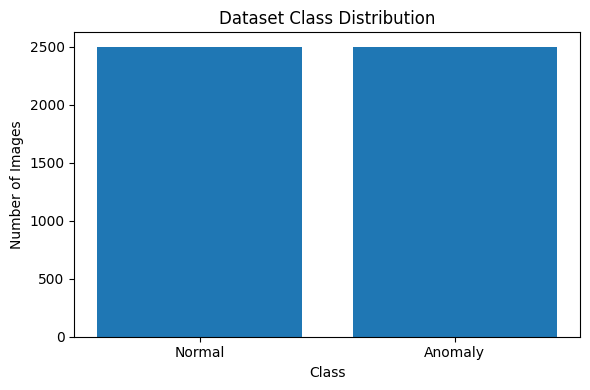

In [3]:
class_counts = df["label_name"].value_counts().rename_axis("Class").reset_index(name="Image Count")
class_counts["Percentage"] = (class_counts["Image Count"] / len(df) * 100).round(2)

display(class_counts)
class_counts.to_csv(TAB_DIR / "class_distribution.csv", index=False)

plt.figure(figsize=(6,4))
plt.bar(class_counts["Class"], class_counts["Image Count"])
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_01_class_distribution.png", dpi=300)
plt.show()

# Cell 4 — Display and save sample image grid


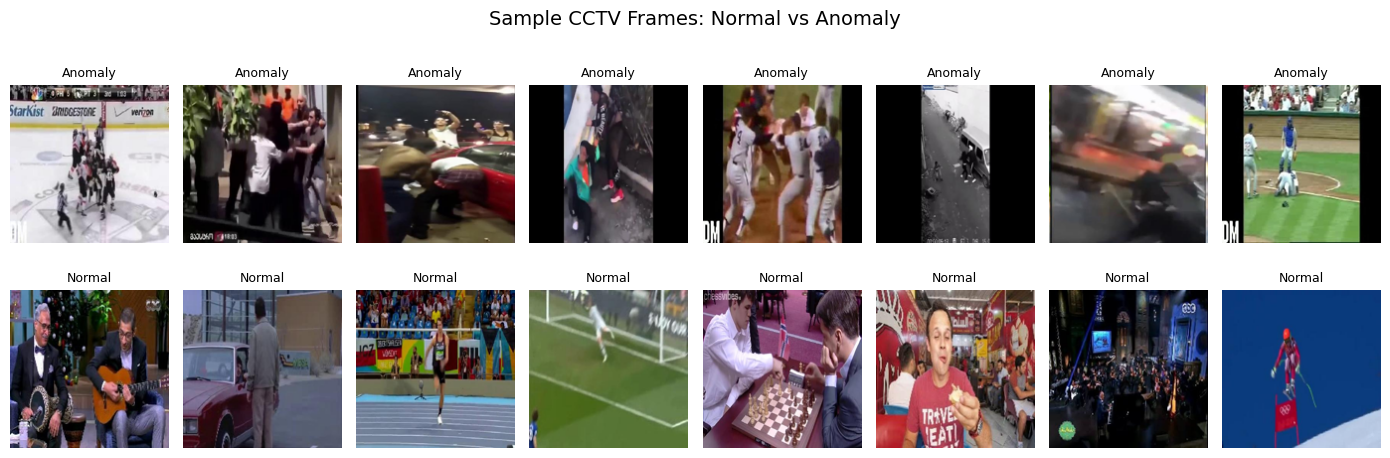

In [4]:
sample_df = df.groupby("label_name", group_keys=False).apply(
    lambda x: x.sample(n=min(8, len(x)), random_state=SEED)
).reset_index(drop=True)

plt.figure(figsize=(14,5))
for i, row in enumerate(sample_df.itertuples(), 1):
    img = Image.open(row.filepath).convert("RGB").resize((160,160))
    plt.subplot(2, 8, i)
    plt.imshow(img)
    plt.title(row.label_name, fontsize=9)
    plt.axis("off")
plt.suptitle("Sample CCTV Frames: Normal vs Anomaly", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_02_sample_images.png", dpi=300)
plt.show()

# Cell 5 — Train/validation/test split

In [5]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"]
)

for name, split in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(name, split.shape)
    display(split["label_name"].value_counts().rename_axis("Class").reset_index(name="Count"))
    split.to_csv(TAB_DIR / f"{name}_split.csv", index=False)

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Images": [len(train_df), len(val_df), len(test_df)]
})
split_summary.to_csv(TAB_DIR / "split_summary.csv", index=False)
display(split_summary)

train (3500, 3)


,Class,Count
0,Anomaly,1750
1,Normal,1750


validation (750, 3)


,Class,Count
0,Anomaly,375
1,Normal,375


test (750, 3)


,Class,Count
0,Anomaly,375
1,Normal,375


,Split,Images
0,Train,3500
1,Validation,750
2,Test,750


# Cell 6 — Build TensorFlow image pipelines

In [6]:


def make_dataset(dataframe, shuffle=False, augment=False, batch_size=BATCH_SIZE):
    paths = dataframe["filepath"].values
    labels = dataframe["label"].astype("float32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.cast(img, tf.float32)
        if augment:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, max_delta=0.08)
            img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
        img = preprocess_input(img)
        return img, label

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(dataframe), 2000), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True, augment=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("Datasets ready.")

I0000 00:00:1778409030.537148      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets ready.


# Cell 7 — Extract MobileNetV2 embeddings for classical ML models

In [7]:


feature_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"
)

def extract_features(dataframe, name):
    ds = make_dataset(dataframe, shuffle=False, augment=False, batch_size=BATCH_SIZE)
    feats = feature_model.predict(ds, verbose=1)
    labels = dataframe["label"].values.astype(int)
    np.save(BASE_OUT / f"{name}_features.npy", feats)
    np.save(BASE_OUT / f"{name}_labels.npy", labels)
    return feats, labels

X_train, y_train = extract_features(train_df, "train")
X_val, y_val = extract_features(val_df, "validation")
X_test, y_test = extract_features(test_df, "test")

print("Feature shapes:", X_train.shape, X_val.shape, X_test.shape)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


I0000 00:00:1778409036.863567     135 service.cc:152] XLA service 0x7b1af80035c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778409036.863603     135 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778409037.476275     135 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778409042.639675     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 261ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
Feature shapes: (3500, 1280) (750, 1280) (750, 1280)


# Cell 8 — Train classical ML and anomaly detection models

In [8]:


def evaluate_predictions(model_name, y_true, y_pred, y_score=None):
    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall_TPR": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": np.nan,
        "Avg_Precision": np.nan
    }
    if y_score is not None and len(np.unique(y_true)) == 2:
        result["ROC_AUC"] = roc_auc_score(y_true, y_score)
        result["Avg_Precision"] = average_precision_score(y_true, y_score)
    return result

results = []

classical_models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced")),
    "Linear SVM": make_pipeline(StandardScaler(), LinearSVC(class_weight="balanced", max_iter=5000)),
    "KNN Classifier": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7)),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=SEED, class_weight="balanced_subsample", n_jobs=-1),
    "MLP Classifier": make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(128,64), max_iter=80, random_state=SEED))
}

for name, clf in classical_models.items():
    t0 = time.time()
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    if hasattr(clf, "predict_proba"):
        score = clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf, "decision_function"):
        score = clf.decision_function(X_test)
    else:
        score = pred

    res = evaluate_predictions(name, y_test, pred, score)
    res["Training_Time_Seconds"] = round(time.time() - t0, 2)
    results.append(res)
    print(name, res)

# Isolation Forest: train mainly on normal training features for anomaly logic
t0 = time.time()
normal_train_features = X_train[y_train == 0]
iso = make_pipeline(
    StandardScaler(),
    IsolationForest(n_estimators=150, contamination=0.15, random_state=SEED, n_jobs=-1)
)
iso.fit(normal_train_features)
iso_raw = iso.predict(X_test)                 # -1 anomaly, 1 normal
iso_pred = np.where(iso_raw == -1, 1, 0)       # 1 anomaly
iso_score = -iso.decision_function(X_test)     # higher means more anomalous
res = evaluate_predictions("Isolation Forest", y_test, iso_pred, iso_score)
res["Training_Time_Seconds"] = round(time.time() - t0, 2)
results.append(res)

classical_results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
classical_results_df.to_csv(TAB_DIR / "classical_model_results.csv", index=False)
display(classical_results_df)

Logistic Regression {'Model': 'Logistic Regression', 'Accuracy': 0.916, 'Precision': 0.9083769633507853, 'Recall_TPR': 0.9253333333333333, 'F1': 0.916776750330251, 'ROC_AUC': np.float64(0.9811626666666667), 'Avg_Precision': np.float64(0.9819149987230188), 'Training_Time_Seconds': 0.9}
Linear SVM {'Model': 'Linear SVM', 'Accuracy': 0.912, 'Precision': 0.9076517150395779, 'Recall_TPR': 0.9173333333333333, 'F1': 0.9124668435013262, 'ROC_AUC': np.float64(0.9756515555555556), 'Avg_Precision': np.float64(0.9764923904128967), 'Training_Time_Seconds': 1.73}
KNN Classifier {'Model': 'KNN Classifier', 'Accuracy': 0.94, 'Precision': 0.9187817258883249, 'Recall_TPR': 0.9653333333333334, 'F1': 0.94148244473342, 'ROC_AUC': np.float64(0.9828693333333333), 'Avg_Precision': np.float64(0.9755443912908438), 'Training_Time_Seconds': 0.32}
Random Forest {'Model': 'Random Forest', 'Accuracy': 0.9213333333333333, 'Precision': 0.9072164948453608, 'Recall_TPR': 0.9386666666666666, 'F1': 0.9226736566186108, 'RO

,Model,Accuracy,Precision,Recall_TPR,F1,ROC_AUC,Avg_Precision,Training_Time_Seconds
4,MLP Classifier,0.949333,0.942257,0.957333,0.949735,0.990976,0.991446,3.26
2,KNN Classifier,0.940000,0.918782,0.965333,0.941482,0.982869,0.975544,0.32
3,Random Forest,0.921333,0.907216,0.938667,0.922674,0.976693,0.975869,5.77
0,Logistic Regression,0.916000,0.908377,0.925333,0.916777,0.981163,0.981915,0.90
1,Linear SVM,0.912000,0.907652,0.917333,0.912467,0.975652,0.976492,1.73
5,Isolation Forest,0.569333,0.642857,0.312000,0.420108,0.625479,0.624552,0.47


# Cell 9 — Classical model comparison figures

<Figure size 1100x500 with 0 Axes>

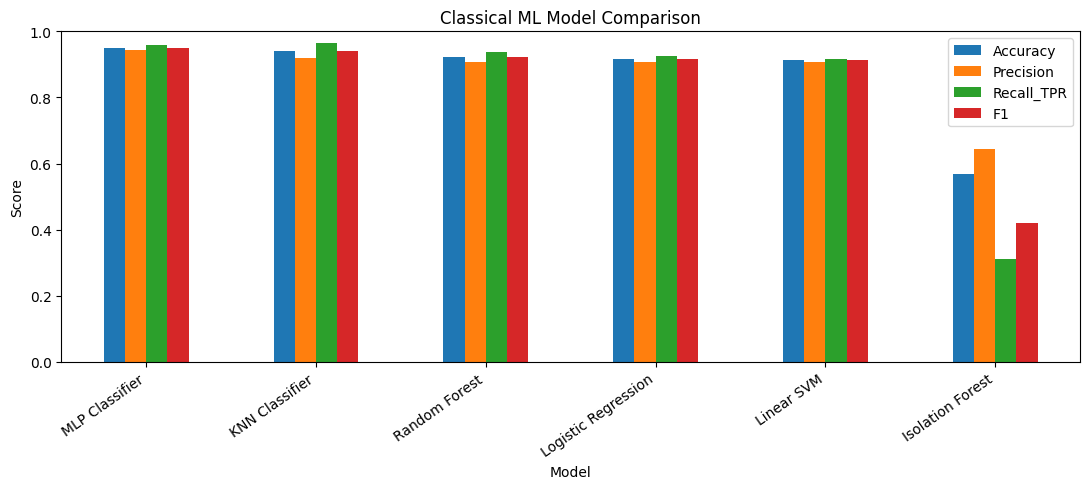

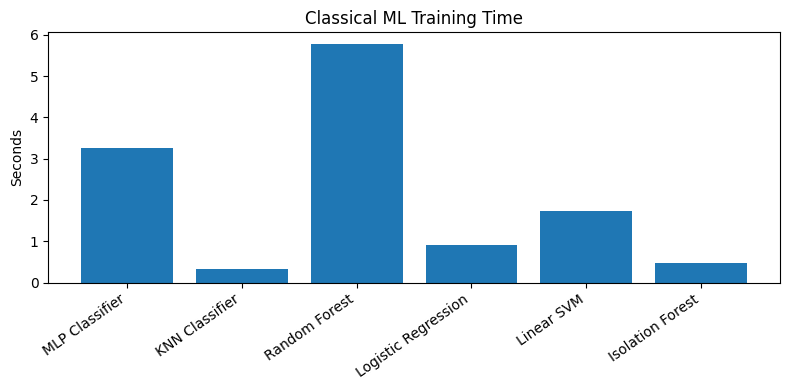

In [9]:


plot_df = classical_results_df.set_index("Model")[["Accuracy", "Precision", "Recall_TPR", "F1", "ROC_AUC"]]

plt.figure(figsize=(11,5))
plot_df[["Accuracy", "Precision", "Recall_TPR", "F1"]].plot(kind="bar", figsize=(11,5))
plt.title("Classical ML Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_03_classical_model_comparison.png", dpi=300)
plt.show()

plt.figure(figsize=(8,4))
plt.bar(classical_results_df["Model"], classical_results_df["Training_Time_Seconds"])
plt.title("Classical ML Training Time")
plt.ylabel("Seconds")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_04_classical_training_time.png", dpi=300)
plt.show()

# Cell 10 — Build a small custom CNN baseline

In [10]:


def build_small_cnn():
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inp, out, name="Small_CNN_Binary_Anomaly")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
    )
    return model

small_cnn = build_small_cnn()
small_cnn.summary()

Model: "Small_CNN_Binary_Anomaly"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

# Cell 11 — Train small CNN

In [11]:


callbacks_small = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(str(MODEL_DIR / "small_cnn_best.keras"), save_best_only=True, monitor="val_loss")
]

t0 = time.time()
hist_small = small_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_SMALL_CNN,
    callbacks=callbacks_small,
    verbose=1
)
small_train_time = round(time.time() - t0, 2)

pd.DataFrame(hist_small.history).to_csv(TAB_DIR / "small_cnn_training_history.csv", index=False)
print("Small CNN training time:", small_train_time, "seconds")

Epoch 1/6
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.5533 - loss: 0.6861 - precision: 0.5583 - recall: 0.6345 - val_accuracy: 0.6493 - val_loss: 0.6541 - val_precision: 0.7617 - val_recall: 0.4347
Epoch 2/6
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6549 - loss: 0.6399 - precision: 0.6451 - recall: 0.6818 - val_accuracy: 0.6960 - val_loss: 0.6029 - val_precision: 0.6754 - val_recall: 0.7547
Epoch 3/6
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6519 - loss: 0.6132 - precision: 0.6460 - recall: 0.7405 - val_accuracy: 0.7213 - val_loss: 0.5554 - val_precision: 0.6930 - val_recall: 0.7947
Epoch 4/6
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7003 - loss: 0.5808 - precision: 0.6940 - recall: 0.7406 - val_accuracy: 0.7240 - val_loss: 0.5878 - val_precision: 0.7069 - val_recall: 0.7653
Epoch 5/6
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6982 - loss: 0.5730 - precision: 0.6858 - recall: 0.7528 - val_accuracy: 0.7653 - val_loss: 0

# Cell 12 — Evaluate small CNN and save plots

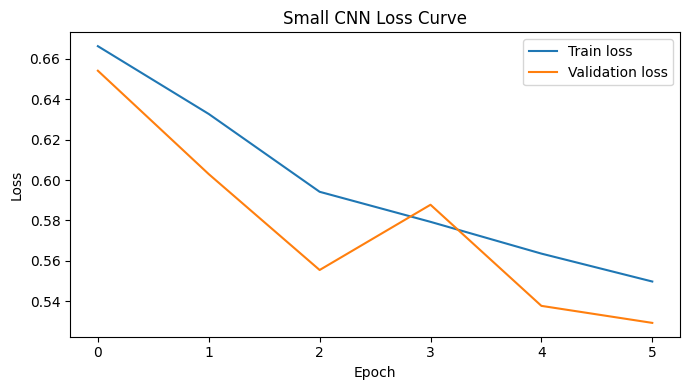

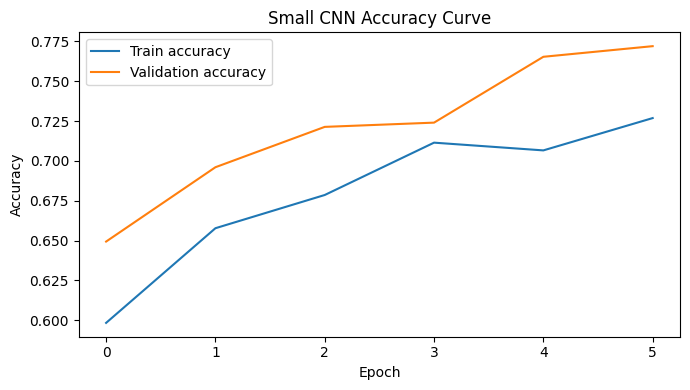

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


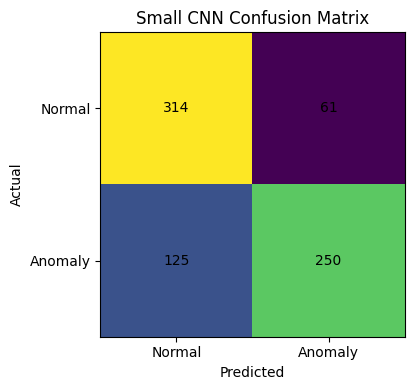

{'Model': 'Small CNN',
 'Accuracy': 0.752,
 'Precision': 0.8038585209003215,
 'Recall_TPR': 0.6666666666666666,
 'F1': 0.7288629737609329,
 'ROC_AUC': np.float64(0.811128888888889),
 'Avg_Precision': np.float64(0.8219455757850471),
 'Training_Time_Seconds': 26.1}

In [12]:


def plot_training_history(history, model_tag):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(7,4))
    plt.plot(hist["loss"], label="Train loss")
    plt.plot(hist["val_loss"], label="Validation loss")
    plt.title(f"{model_tag} Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_tag.lower().replace(' ', '_')}_loss_curve.png", dpi=300)
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(hist["accuracy"], label="Train accuracy")
    plt.plot(hist["val_accuracy"], label="Validation accuracy")
    plt.title(f"{model_tag} Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_tag.lower().replace(' ', '_')}_accuracy_curve.png", dpi=300)
    plt.show()

def evaluate_keras_model(model, dataframe, ds, model_name, training_time):
    y_true = dataframe["label"].values.astype(int)
    y_score = model.predict(ds, verbose=1).ravel()
    y_pred = (y_score >= 0.5).astype(int)

    res = evaluate_predictions(model_name, y_true, y_pred, y_score)
    res["Training_Time_Seconds"] = training_time

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=["Actual Normal", "Actual Anomaly"], columns=["Pred Normal", "Pred Anomaly"])
    cm_df.to_csv(TAB_DIR / f"{model_name.lower().replace(' ', '_')}_confusion_matrix.csv")

    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xticks([0,1], ["Normal", "Anomaly"])
    plt.yticks([0,1], ["Normal", "Anomaly"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i,j], ha="center", va="center")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png", dpi=300)
    plt.show()

    report = classification_report(y_true, y_pred, target_names=["Normal", "Anomaly"], output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(TAB_DIR / f"{model_name.lower().replace(' ', '_')}_classification_report.csv")

    return res, y_true, y_pred, y_score

plot_training_history(hist_small, "Small CNN")
small_res, small_y_true, small_y_pred, small_y_score = evaluate_keras_model(
    small_cnn, test_df, test_ds, "Small CNN", small_train_time
)
small_res

# Cell 13 — Build MobileNetV2 transfer learning model

In [13]:


def build_mobilenet_transfer():
    base = MobileNetV2(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling="avg")
    base.trainable = False

    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inp, training=False)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inp, out, name="MobileNetV2_Transfer_Binary_Anomaly")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
    )
    return model

transfer_model = build_mobilenet_transfer()
transfer_model.summary()

Model: "MobileNetV2_Transfer_Binary_Anomaly"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Cell 14 — Train MobileNetV2 transfer model

In [14]:


callbacks_transfer = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(str(MODEL_DIR / "mobilenetv2_transfer_best.keras"), save_best_only=True, monitor="val_loss")
]

t0 = time.time()
hist_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TRANSFER,
    callbacks=callbacks_transfer,
    verbose=1
)
transfer_train_time = round(time.time() - t0, 2)

pd.DataFrame(hist_transfer.history).to_csv(TAB_DIR / "mobilenetv2_training_history.csv", index=False)
print("MobileNetV2 transfer training time:", transfer_train_time, "seconds")

Epoch 1/6
110/110 ━━━━━━━━━━━━━━━━━━━━ 25s 142ms/step - accuracy: 0.6349 - loss: 0.6743 - precision: 0.6357 - recall: 0.6465 - val_accuracy: 0.8813 - val_loss: 0.2920 - val_precision: 0.8783 - val_recall: 0.8853
Epoch 2/6
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8653 - loss: 0.3200 - precision: 0.8657 - recall: 0.8761 - val_accuracy: 0.9013 - val_loss: 0.2349 - val_precision: 0.8992 - val_recall: 0.9040
Epoch 3/6
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8897 - loss: 0.2788 - precision: 0.8922 - recall: 0.8827 - val_accuracy: 0.9160 - val_loss: 0.2147 - val_precision: 0.9084 - val_recall: 0.9253
Epoch 4/6
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9026 - loss: 0.2438 - precision: 0.9046 - recall: 0.9006 - val_accuracy: 0.9227 - val_loss: 0.1998 - val_precision: 0.9272 - val_recall: 0.9173
Epoch 5/6
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9090 - loss: 0.2129 - precision: 0.9125 - recall: 0.9086 - val_accuracy: 0.9240 - val_loss: 

# Cell 15 — Evaluate MobileNetV2 with ROC and Precision-Recall curves

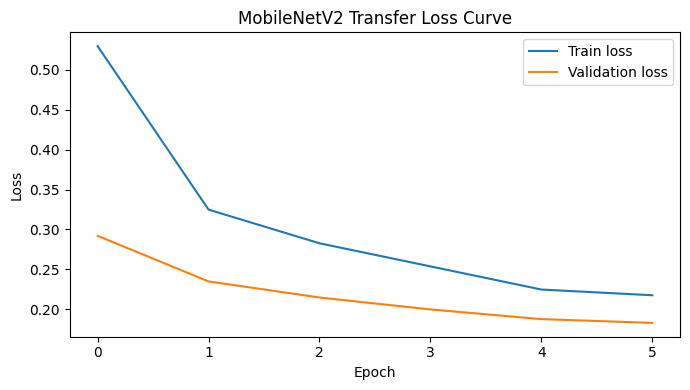

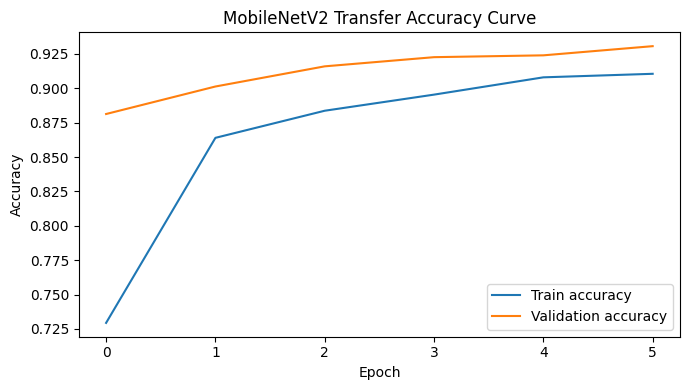

24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 201ms/step


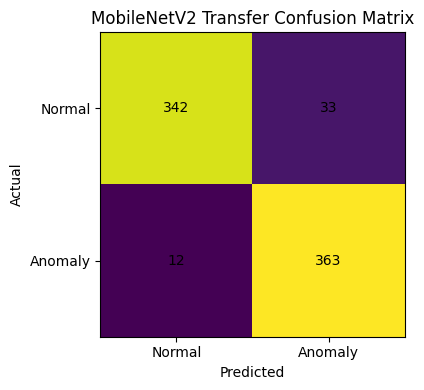

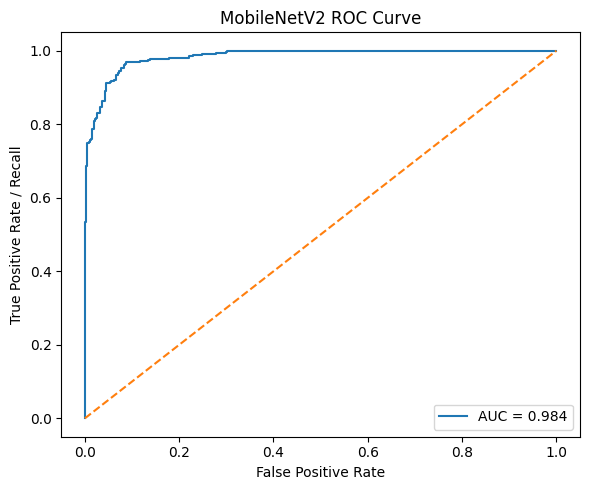

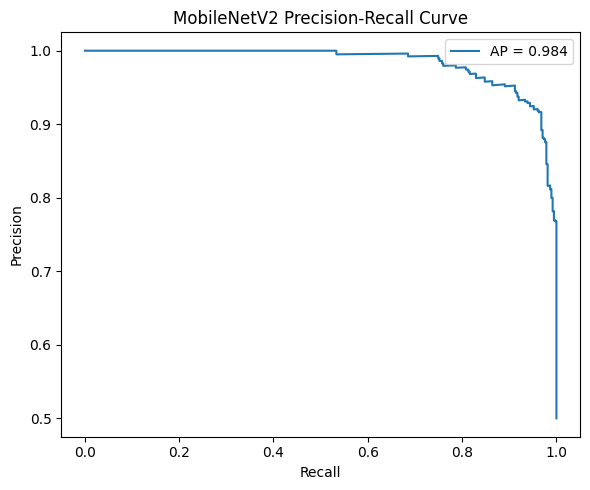

{'Model': 'MobileNetV2 Transfer',
 'Accuracy': 0.94,
 'Precision': 0.9166666666666666,
 'Recall_TPR': 0.968,
 'F1': 0.9416342412451362,
 'ROC_AUC': np.float64(0.9837511111111111),
 'Avg_Precision': np.float64(0.9839507837388457),
 'Training_Time_Seconds': 43.92}

In [15]:


plot_training_history(hist_transfer, "MobileNetV2 Transfer")

transfer_res, trans_y_true, trans_y_pred, trans_y_score = evaluate_keras_model(
    transfer_model, test_df, test_ds, "MobileNetV2 Transfer", transfer_train_time
)

# ROC curve
fpr, tpr, roc_thresholds = roc_curve(trans_y_true, trans_y_score)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(trans_y_true, trans_y_score):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("MobileNetV2 ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_09_mobilenetv2_roc_curve.png", dpi=300)
plt.show()

# Precision-recall curve
prec, rec, pr_thresholds = precision_recall_curve(trans_y_true, trans_y_score)
plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"AP = {average_precision_score(trans_y_true, trans_y_score):.3f}")
plt.title("MobileNetV2 Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_10_mobilenetv2_precision_recall_curve.png", dpi=300)
plt.show()

# Save prediction log
pred_log = test_df.copy()
pred_log["anomaly_probability"] = trans_y_score
pred_log["predicted_label"] = trans_y_pred
pred_log["predicted_status"] = np.where(pred_log["predicted_label"] == 1, "ALERT: Violence Anomaly", "Normal")
pred_log.to_csv(TAB_DIR / "mobilenetv2_test_prediction_log.csv", index=False)

transfer_res

# Cell 16 — Final model comparison table and comparison figure

,Model,Accuracy,Precision,Recall_TPR,F1,ROC_AUC,Avg_Precision,Training_Time_Seconds
0,MLP Classifier,0.949333,0.942257,0.957333,0.949735,0.990976,0.991446,3.26
1,MobileNetV2 Transfer,0.940000,0.916667,0.968000,0.941634,0.983751,0.983951,43.92
2,KNN Classifier,0.940000,0.918782,0.965333,0.941482,0.982869,0.975544,0.32
3,Random Forest,0.921333,0.907216,0.938667,0.922674,0.976693,0.975869,5.77
4,Logistic Regression,0.916000,0.908377,0.925333,0.916777,0.981163,0.981915,0.90
5,Linear SVM,0.912000,0.907652,0.917333,0.912467,0.975652,0.976492,1.73
6,Small CNN,0.752000,0.803859,0.666667,0.728863,0.811129,0.821946,26.10
7,Isolation Forest,0.569333,0.642857,0.312000,0.420108,0.625479,0.624552,0.47


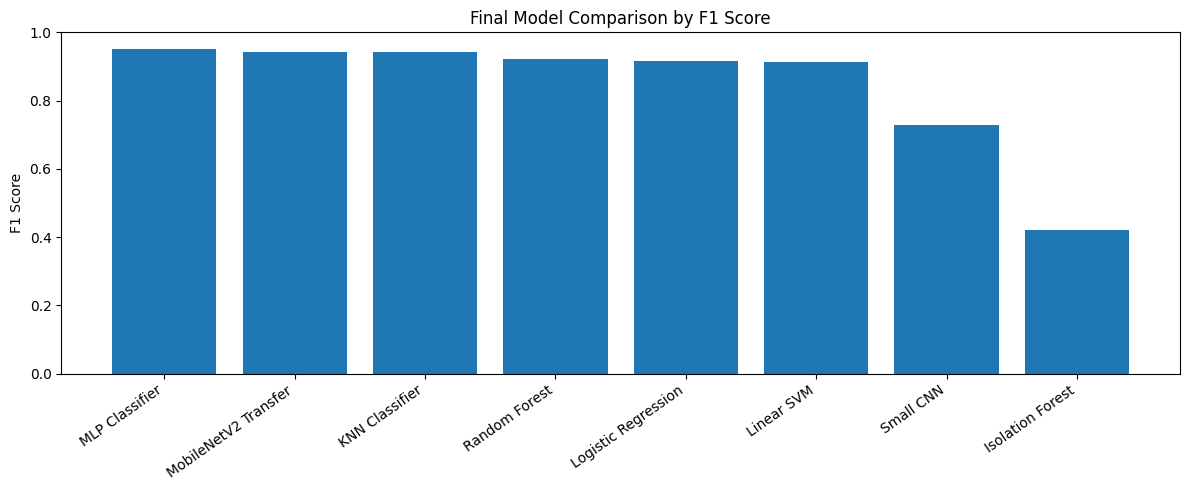

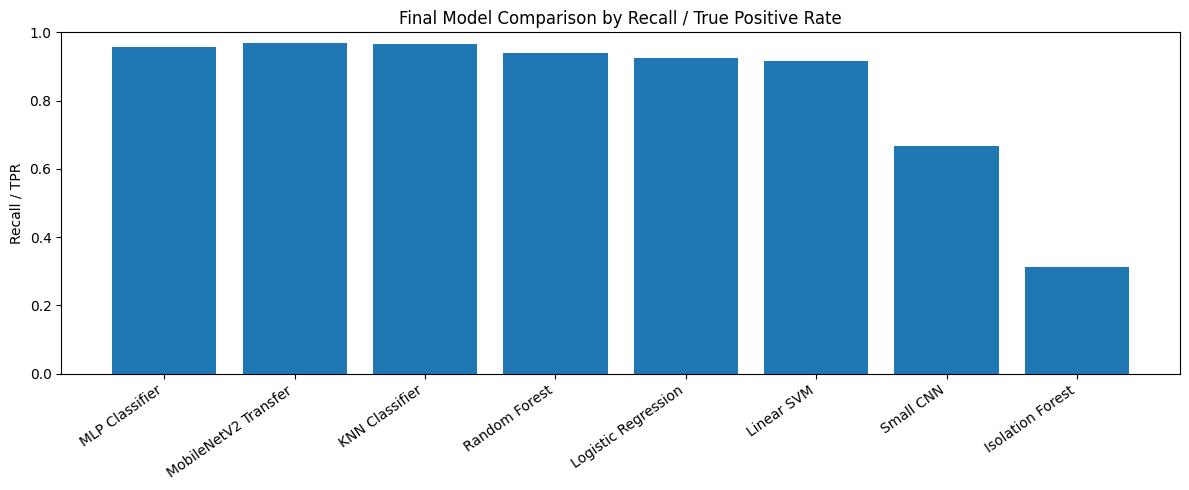

Best model based on F1: MLP Classifier


In [16]:


deep_results_df = pd.DataFrame([small_res, transfer_res])
final_results_df = pd.concat([classical_results_df, deep_results_df], ignore_index=True)
final_results_df = final_results_df.sort_values("F1", ascending=False).reset_index(drop=True)

final_results_df.to_csv(TAB_DIR / "final_model_comparison.csv", index=False)
display(final_results_df)

plt.figure(figsize=(12,5))
plt.bar(final_results_df["Model"], final_results_df["F1"])
plt.title("Final Model Comparison by F1 Score")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_11_final_model_comparison_f1.png", dpi=300)
plt.show()

plt.figure(figsize=(12,5))
plt.bar(final_results_df["Model"], final_results_df["Recall_TPR"])
plt.title("Final Model Comparison by Recall / True Positive Rate")
plt.ylabel("Recall / TPR")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_12_final_model_comparison_recall.png", dpi=300)
plt.show()

best_model_name = final_results_df.iloc[0]["Model"]
print("Best model based on F1:", best_model_name)

# Cell 17 — Alert demo: show predictions on random test images


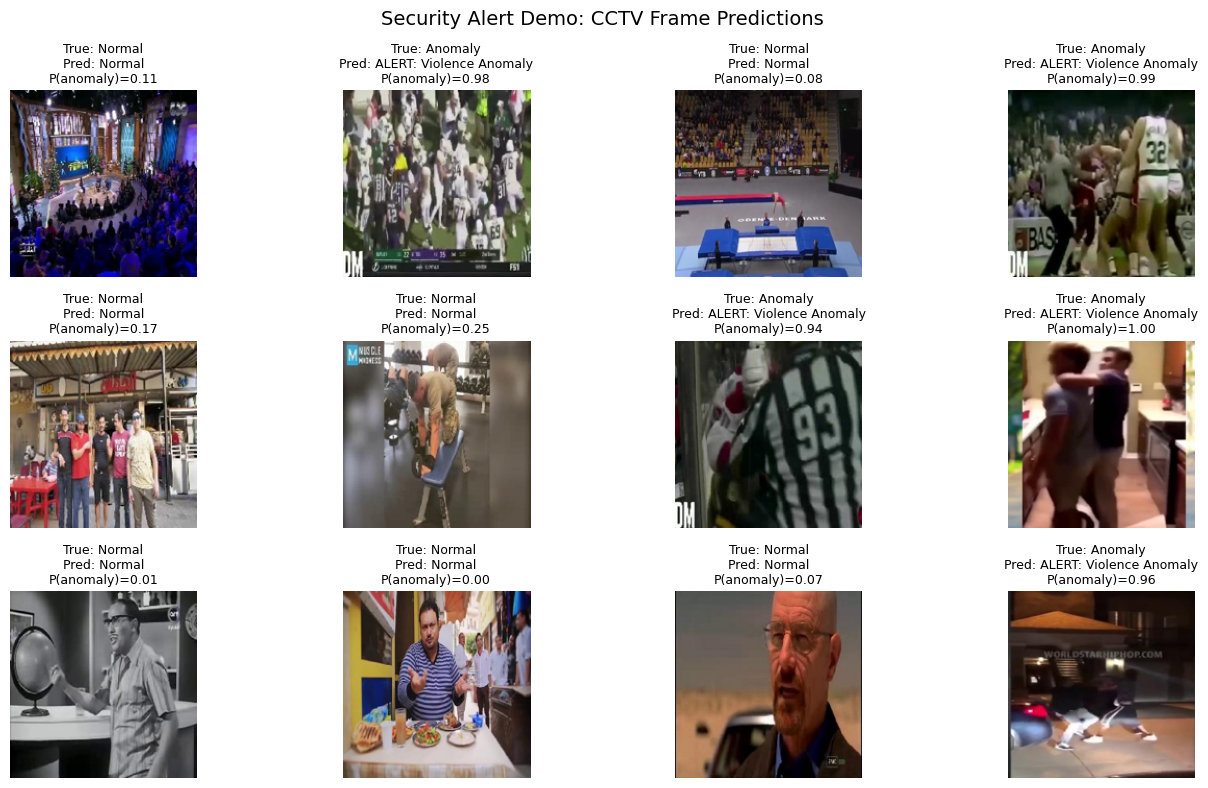

,filepath,label,label_name,anomaly_probability,predicted_label,predicted_status,alert_message
3704,/kaggle/input/datasets/abdulmananraja/real-lif...,1,Anomaly,0.995066,1,ALERT: Violence Anomaly,Potential violence anomaly detected. Send to s...
1509,/kaggle/input/datasets/abdulmananraja/real-lif...,0,Normal,0.920298,1,ALERT: Violence Anomaly,Potential violence anomaly detected. Send to s...
2673,/kaggle/input/datasets/abdulmananraja/real-lif...,1,Anomaly,0.754892,1,ALERT: Violence Anomaly,Potential violence anomaly detected. Send to s...
3864,/kaggle/input/datasets/abdulmananraja/real-lif...,1,Anomaly,0.988694,1,ALERT: Violence Anomaly,Potential violence anomaly detected. Send to s...
883,/kaggle/input/datasets/abdulmananraja/real-lif...,1,Anomaly,0.904102,1,ALERT: Violence Anomaly,Potential violence anomaly detected. Send to s...
1737,/kaggle/input/datasets/abdulmananraja/real-lif...,1,Anomaly,0.979494,1,ALERT: Violence Anomaly,Potential violence anomaly detected. Send to s...
864,/kaggle/input/datasets/abdulmananraja/real-lif...,1,Anomaly,0.883399,1,ALERT: Violence Anomaly,Potential violence anomaly detected. Send to s...
1526,/kaggle/input/datasets/abdulmananraja/real-lif...,1,Anomaly,0.879015,1,ALERT: Violence Anomaly,Potential violence anomaly detected. Send to s...
3116,/kaggle/input/datasets/abdulmananraja/real-lif...,0,Normal,0.634670,1,ALERT: Violence Anomaly,Potential violence anomaly detected. Send to s...
2945,/kaggle/input/datasets/abdulmananraja/real-lif...,0,Normal,0.659082,1,ALERT: Violence Anomaly,Potential violence anomaly detected. Send to s...


Total predicted alerts: 396


In [17]:

demo_df = pred_log.sample(n=min(12, len(pred_log)), random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(14,8))
for i, row in enumerate(demo_df.itertuples(), 1):
    img = Image.open(row.filepath).convert("RGB").resize((180,180))
    plt.subplot(3,4,i)
    plt.imshow(img)
    title = f"True: {row.label_name}\nPred: {row.predicted_status}\nP(anomaly)={row.anomaly_probability:.2f}"
    plt.title(title, fontsize=9)
    plt.axis("off")
plt.suptitle("Security Alert Demo: CCTV Frame Predictions", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_13_alert_demo_predictions.png", dpi=300)
plt.show()

# Create alert log: only frames predicted as anomaly
alert_log = pred_log[pred_log["predicted_label"] == 1].copy()
alert_log["alert_message"] = "Potential violence anomaly detected. Send to security operator for review."
alert_log[["filepath", "label_name", "anomaly_probability", "predicted_status", "alert_message"]].to_csv(
    TAB_DIR / "security_alert_log.csv", index=False
)
display(alert_log.head(10))
print("Total predicted alerts:", len(alert_log))

# Cell 18 — System architecture diagram, report asset index, and ZIP export

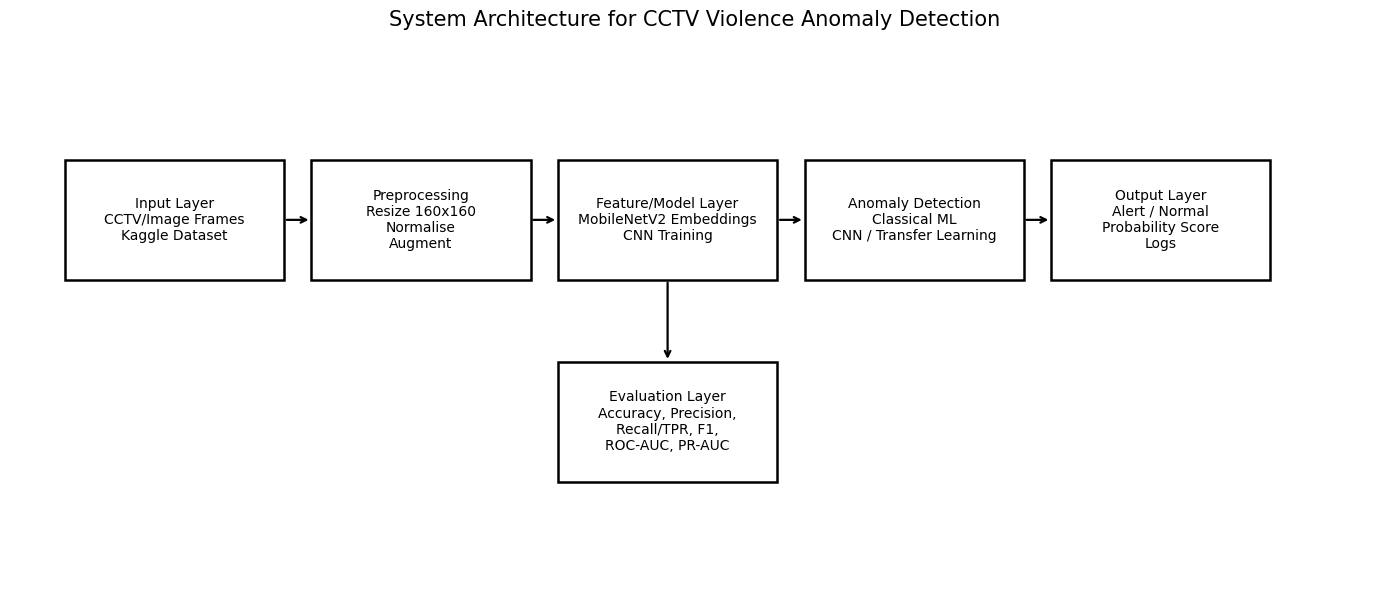

,Asset_Type,Filename,Suggested_Report_Use
0,Figure,figure_01_class_distribution.png,Insert in implementation/evaluation section
1,Figure,figure_02_sample_images.png,Insert in implementation/evaluation section
2,Figure,figure_03_classical_model_comparison.png,Insert in implementation/evaluation section
3,Figure,figure_04_classical_training_time.png,Insert in implementation/evaluation section
4,Figure,figure_09_mobilenetv2_roc_curve.png,Insert in implementation/evaluation section
5,Figure,figure_10_mobilenetv2_precision_recall_curve.png,Insert in implementation/evaluation section
6,Figure,figure_11_final_model_comparison_f1.png,Insert in implementation/evaluation section
7,Figure,figure_12_final_model_comparison_recall.png,Insert in implementation/evaluation section
8,Figure,figure_13_alert_demo_predictions.png,Insert in implementation/evaluation section
9,Figure,figure_14_system_architecture.png,Insert in implementation/evaluation section


DONE.
Download this ZIP from Kaggle output:
/kaggle/working/cctv_violence_anomaly_outputs.zip


In [18]:


# Simple architecture diagram using matplotlib
plt.figure(figsize=(14,6))
plt.axis("off")

boxes = [
    (0.04, 0.55, "Input Layer\nCCTV/Image Frames\nKaggle Dataset"),
    (0.22, 0.55, "Preprocessing\nResize 160x160\nNormalise\nAugment"),
    (0.40, 0.55, "Feature/Model Layer\nMobileNetV2 Embeddings\nCNN Training"),
    (0.58, 0.55, "Anomaly Detection\nClassical ML\nCNN / Transfer Learning"),
    (0.76, 0.55, "Output Layer\nAlert / Normal\nProbability Score\nLogs"),
    (0.40, 0.18, "Evaluation Layer\nAccuracy, Precision,\nRecall/TPR, F1,\nROC-AUC, PR-AUC")
]

for x, y, text in boxes:
    rect = plt.Rectangle((x, y), 0.16, 0.22, fill=False, linewidth=1.8)
    plt.gca().add_patch(rect)
    plt.text(x+0.08, y+0.11, text, ha="center", va="center", fontsize=10)

for i in range(4):
    x1 = boxes[i][0] + 0.16
    y1 = boxes[i][1] + 0.11
    x2 = boxes[i+1][0]
    y2 = boxes[i+1][1] + 0.11
    plt.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="->", linewidth=1.6))

plt.annotate("", xy=(0.48, 0.40), xytext=(0.48, 0.55), arrowprops=dict(arrowstyle="->", linewidth=1.6))
plt.title("System Architecture for CCTV Violence Anomaly Detection", fontsize=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_14_system_architecture.png", dpi=300)
plt.show()

# Report asset checklist
asset_rows = []
for p in sorted(FIG_DIR.glob("*.png")):
    asset_rows.append({"Asset_Type": "Figure", "Filename": p.name, "Suggested_Report_Use": "Insert in implementation/evaluation section"})
for p in sorted(TAB_DIR.glob("*.csv")):
    asset_rows.append({"Asset_Type": "Table/CSV", "Filename": p.name, "Suggested_Report_Use": "Use for report tables or appendix"})

asset_index = pd.DataFrame(asset_rows)
asset_index.to_csv(BASE_OUT / "report_asset_index.csv", index=False)
display(asset_index)

# Save brief project summary JSON
summary = {
    "project_title": "CCTV Surveillance Violence Anomaly Detection",
    "dataset": "Violence vs. Non-Violence: 11K Images Dataset",
    "labels": {"0": "Normal / Non-Violence", "1": "Anomaly / Violence"},
    "image_size": IMG_SIZE,
    "max_per_class": MAX_PER_CLASS,
    "best_model_by_f1": str(best_model_name),
    "outputs_folder": str(BASE_OUT)
}
with open(BASE_OUT / "project_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

# Zip all outputs
zip_path = Path("/kaggle/working/cctv_violence_anomaly_outputs.zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for file in BASE_OUT.rglob("*"):
        z.write(file, file.relative_to(BASE_OUT.parent))

print("DONE.")
print("Download this ZIP from Kaggle output:")
print(zip_path)